In [1]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
data.target[[10, 50, 85]]

array([0, 1, 0])

#Comprensión del problema

Antes de escribir código:

- ¿Cuál es el objetivo del caso?
    > Clasificar cáncer de mama (predecir con base a las mediciones si existe alguna presciencia benigna)
- ¿Qué variable deseas predecir o analizar?
    > Maligno o Benigno
- ¿Es clasificación, regresión, clustering o series de tiempo?
    > Clasificación

Estas respuestas deben quedar registradas en la hoja de trabajo.

# Data Exploration

In [2]:
print(list(data.target_names))
print(len(data.data))
print(data.feature_names)

[np.str_('malignant'), np.str_('benign')]
569
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [3]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [4]:
# Find missing data in rows
import numpy as np
np.isnan(data.data).sum()

np.int64(0)

In [5]:
# Find duplicate data
import pandas as pd
df = pd.DataFrame(data.data, columns=data.feature_names)
df.duplicated().sum()

np.int64(0)

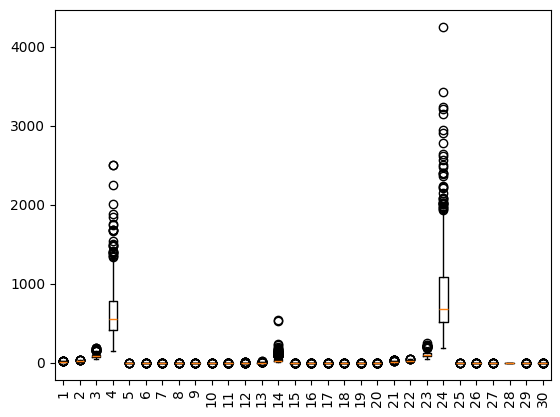

In [6]:
# Find outliers
import matplotlib.pyplot as plt
plt.boxplot(data.data)
plt.xticks(rotation=90)
plt.show()

# Prepare Data Set

In [7]:
# Divide data into test and train sets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistical Regression

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = data.data
y = data.target

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, solver="lbfgs", random_state=42)
)

model.fit(X_train, y_train)

lr_predictions = model.predict(X_test)

print("Coeficientes:", model.named_steps["logisticregression"].coef_)
print("Intercepto:", model.named_steps["logisticregression"].intercept_)
print("Accuracy:", model.score(X_test, y_test))

print("Accuracy Logistic Regression:", accuracy_score(y_test, lr_predictions))
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, lr_predictions))
print()
print(classification_report(y_test, lr_predictions, target_names=data.target_names))

Coeficientes: [[-0.43190368 -0.38732553 -0.39343248 -0.46521006 -0.07166728  0.54016395
  -0.8014581  -1.11980408  0.23611852  0.07592093 -1.26817815  0.18887738
  -0.61058302 -0.9071857  -0.31330675  0.68249145  0.17527452 -0.3112999
   0.50042502  0.61622993 -0.87984024 -1.35060559 -0.58945273 -0.84184594
  -0.54416967  0.01611019 -0.94305313 -0.77821726 -1.20820031 -0.15741387]]
Intercepto: [0.44558453]
Accuracy: 0.9736842105263158
Accuracy Logistic Regression: 0.9736842105263158

Matriz de confusión:
[[41  2]
 [ 1 70]]

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# kNN

In [9]:
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_predictions = knn.predict(X_test_scaled)

print("Accuracy kNN:", accuracy_score(y_test, knn_predictions))
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, knn_predictions))
print()
print(classification_report(y_test, knn_predictions, target_names=data.target_names))

Accuracy kNN: 0.9473684210526315

Matriz de confusión:
[[40  3]
 [ 3 68]]

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



# Naive Bayes

In [10]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

print("Accuracy Naive Bayes:", accuracy_score(y_test, nb_predictions))
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, nb_predictions))
print()
print(classification_report(y_test, nb_predictions, target_names=data.target_names))

Accuracy Naive Bayes: 0.9736842105263158

Matriz de confusión:
[[40  3]
 [ 0 71]]

              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        43
      benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# SVC

In [11]:
from sklearn.svm import SVC

svm = SVC(kernel="linear", probability=True, random_state=42)

svm.fit(X_train_scaled, y_train)

svm_predictions = svm.predict(X_test_scaled)

print("Accuracy SVM:", accuracy_score(y_test, svm_predictions))
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, svm_predictions))
print()
print(classification_report(y_test, svm_predictions, target_names=data.target_names))

Accuracy SVM: 0.956140350877193

Matriz de confusión:
[[41  2]
 [ 3 68]]

              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [12]:
models_results = pd.DataFrame({
    "Modelo": ["kNN", "Logistic Regression", "Naive Bayes", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, knn_predictions),
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, svm_predictions)
    ]
})

models_results

,Modelo,Accuracy
0,kNN,0.947368
1,Logistic Regression,0.973684
2,Naive Bayes,0.973684
3,SVM,0.956140
